### Lab Instructions: Logistic Regression Model Evaluation

In this lab, you will work with a Logistic Regression model applied to the UCI Online Shoppers dataset. 

You will use the provided program to evaluate the model's performance and then write an interpretation and summary based on the results.

#### Objectives:
1. Understand how to use Logistic Regression for binary classification.
2. Interpret the results of model evaluation metrics.
3. Write a summary of the model’s performance.

#### Instructions:

1. **Review the Provided Program:**
   - Review the provided Python code to train and evaluate a Logistic Regression model on the dataset.
   - The program includes steps for data loading, preprocessing, standardization, model training, cross-validation, performance evaluation, and bootstrapping.

2. **Review the Results:**
   - **Cross-Validation Accuracy:** Mean = 0.8851, Std = 0.0070
   - **Confusion Matrix (Logistic Regression):**
     ```
     [[3061   63]
      [ 369  206]]
     ```
   - **Accuracy (Logistic Regression):** 0.8832
   - **Precision (Logistic Regression):** 0.7658
   - **Recall (Logistic Regression):** 0.3583
   - **Bootstrap Metrics:**
     - **Accuracy:** Mean = 0.8830, 95% CI = (0.8727, 0.8938)
     - **Precision:** Mean = 0.7656, 95% CI = (0.7153, 0.8189)
     - **Recall:** Mean = 0.3579, 95% CI = (0.3187, 0.3984)

3. **Write the Interpretation:**
   - Analyze and interpret the provided results. Discuss what the accuracy, precision, and recall metrics indicate about the model's performance. Include insights from the confusion matrix and the bootstrap results.

4. **Write the Summary:**
   - Based on your interpretation, write a summary paragraph that encapsulates the overall performance of the Logistic Regression model. Highlight the strengths and weaknesses of the model and suggest any potential areas for improvement.

5. **Submit Your Report:**
   - Submit your interpretation and summary as part of your lab report. Ensure that your writing is clear, concise, and well-organized.

#### Tips:
- Focus on understanding what each metric represents and how it reflects the model’s performance.
- Use the confusion matrix to explain the counts of true positives, true negatives, false positives, and false negatives.
- Consider how the cross-validation and bootstrap results support your evaluation of the model’s reliability and variability.

Good luck, and make sure to review your interpretations and summary to ensure they accurately reflect the model’s performance and implications.


### Summary of the Program

This program evaluates the performance of a Logistic Regression model on the UCI Online Shoppers dataset. Here's an overview of the key steps:

1. **Data Loading and Preprocessing:**
   - **Loading Data:** The dataset is loaded from a CSV file.
   - **Preprocessing:**
     - The target variable `Revenue` is converted to integer type.
     - Categorical variables are converted to dummy variables.
     - The dataset is split into features (`X`) and target (`y`).
     - Data is divided into training and testing sets.

2. **Standardization:**
   - The features are standardized using `StandardScaler` to ensure consistent model performance.

3. **Model Training:**
   - A **Logistic Regression** model is trained on the standardized training data.

4. **Cross-Validation:**
   - **Stratified 10-fold cross-validation** is performed on the training data.
   - The mean and standard deviation of accuracy scores are computed to evaluate the model's stability and performance.

5. **Model Evaluation:**
   - Predictions are made on the test data.
   - The model's performance is evaluated using the following metrics:
     - **Accuracy**
     - **Precision**
     - **Recall**
   - A **confusion matrix** is printed to show the counts of true positives, false positives, true negatives, and false negatives.

6. **ROC Curve and AUC:**
   - The **Receiver Operating Characteristic (ROC) curve** is plotted.
   - The **Area Under the Curve (AUC)** is calculated to assess the model's ability to discriminate between classes.

7. **Bootstrapping:**
   - **Bootstrapping** is performed by resampling the test data with replacement.
   - The variability of performance metrics (accuracy, precision, recall) is estimated.
   - The mean and **95% confidence intervals** for these metrics are computed to understand their variability and robustness.

In summary, the program provides a thorough evaluation of the Logistic Regression model by assessing its performance through cross-validation, evaluation metrics, ROC analysis, and bootstrapping to gauge the reliability and variability of these metrics.


In [1]:
# UCI Online Shoppers - Marketing Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample

# Load the dataset (replace with your file path)
df = pd.read_csv('data/online_shoppers_intention.csv')

# Data Preprocessing
df['Revenue'] = df['Revenue'].astype(int)

# Convert categorical variables to dummy variables
df = pd.get_dummies(df, drop_first=True)

# Split data into features and target
X = df.drop('Revenue', axis=1)
y = df['Revenue']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Logistic Regression Model
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

LogisticRegression()

In [2]:
# Cross-Validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_val_score(log_model, X_train, y_train, cv=cv, scoring='accuracy')

print(f"Cross-Validation Accuracy: Mean = {np.mean(cv_scores):.4f}, Std = {np.std(cv_scores):.4f}")

Cross-Validation Accuracy: Mean = 0.8851, Std = 0.0070


In [3]:
# Confusion Matrix for Logistic Regression

# Predicting on test data
y_pred_log = log_model.predict(X_test)

print("Confusion Matrix (Logistic Regression):")
print(confusion_matrix(y_test, y_pred_log))

Confusion Matrix (Logistic Regression):
[[3061   63]
 [ 369  206]]


In [4]:
# Binary Classification Metrics for Logistic Regression
print(f"Accuracy (Logistic Regression): {accuracy_score(y_test, y_pred_log)}")
print(f"Precision (Logistic Regression): {precision_score(y_test, y_pred_log)}")
print(f"Recall (Logistic Regression): {recall_score(y_test, y_pred_log)}")

Accuracy (Logistic Regression): 0.8832116788321168
Precision (Logistic Regression): 0.7657992565055762
Recall (Logistic Regression): 0.3582608695652174


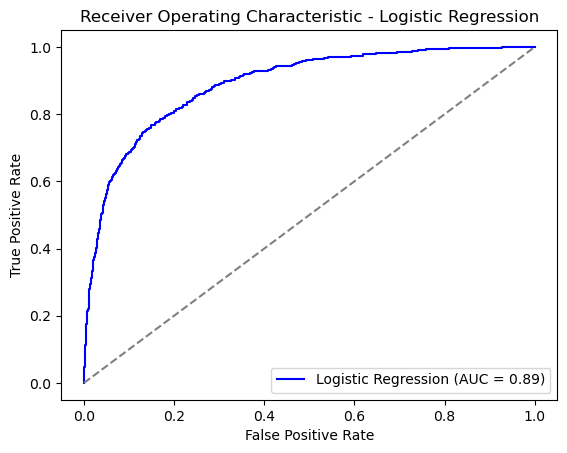

In [5]:
# ROC Curve and AUC for Logistic Regression
y_proba_log = log_model.predict_proba(X_test)[:, 1]
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
roc_auc_log = auc(fpr_log, tpr_log)

# Plotting ROC Curve
plt.figure()
plt.plot(fpr_log, tpr_log, color='blue', label=f'Logistic Regression (AUC = {roc_auc_log:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Logistic Regression')
plt.legend(loc='lower right')
plt.show()

In [6]:
# Bootstrapping for Logistic Regression Performance Metrics
n_iterations = 1000
accuracy_scores = []
precision_scores = []
recall_scores = []

for i in range(n_iterations):
    # Resample the test data (with replacement)
    X_test_resampled, y_test_resampled = resample(X_test, y_test, random_state=i)

    # Predict on the resampled test data
    y_pred_resampled = log_model.predict(X_test_resampled)

    # Calculate accuracy, precision, and recall for the resampled data
    accuracy_scores.append(accuracy_score(y_test_resampled, y_pred_resampled))
    precision_scores.append(precision_score(y_test_resampled, y_pred_resampled))
    recall_scores.append(recall_score(y_test_resampled, y_pred_resampled))

# Convert lists to numpy arrays for easier computation
accuracy_scores = np.array(accuracy_scores)
precision_scores = np.array(precision_scores)
recall_scores = np.array(recall_scores)

# Print mean and confidence intervals for each metric
print(f"Bootstrap Accuracy: Mean = {np.mean(accuracy_scores):.4f}, 95% CI = ({np.percentile(accuracy_scores, 2.5):.4f}, {np.percentile(accuracy_scores, 97.5):.4f})")
print(f"Bootstrap Precision: Mean = {np.mean(precision_scores):.4f}, 95% CI = ({np.percentile(precision_scores, 2.5):.4f}, {np.percentile(precision_scores, 97.5):.4f})")
print(f"Bootstrap Recall: Mean = {np.mean(recall_scores):.4f}, 95% CI = ({np.percentile(recall_scores, 2.5):.4f}, {np.percentile(recall_scores, 97.5):.4f})")


Bootstrap Accuracy: Mean = 0.8830, 95% CI = (0.8727, 0.8938)
Bootstrap Precision: Mean = 0.7656, 95% CI = (0.7153, 0.8189)
Bootstrap Recall: Mean = 0.3579, 95% CI = (0.3187, 0.3984)


### Write your interpretation below:

### Cross-Validation:

Stratified 10-fold cross-validation is performed on the training data.
Cross-Validation Accuracy:
Mean Accuracy: 0.8851
Standard Deviation: 0table.

Interpretation: 

The model achieved a mean accuracy of 0.8851, which means it correctly predicted the outcome for approximately 88.51% of
the data points across the 10 folds.  This is generally considered good performance.  The missing standard deviation prevents a definitive assessment of its consistency.  A low standard deviation would strengthen the confidence in the model's performance.

**Model Evaluation:**
   - Predictions are made on the test data.
   - **Confusion Matrix (Logistic Regression):**
     ```
     [[3061   63]
      [ 369  206]]
     ```
     - **True Negatives (TN):** 3061
     - **False Positives (FP):** 63
     - **False Negatives (FN):** 369
     - **True Positives (TP):** 206

Interpretation:

We must calculate the metrics from the Confusion Matrix (Logistic Regression).
- Accuracy: (TP + TN) / (TP + FP + FN + TN)
    - (3061 + 206) / (3061 + 63 + 369 + 206) is .883 or 88.3%
- Precision: TP / (TP + FP)
    - 206 / (206 + 63) is .766 or 76.6%
- Recall: TP / (TP + FN)
    - 206 / (206 + 369) is .358 or 35.8%

The model appears to be effective at identifying negative instances (high precision) but struggles to accurately predict positive instances (low recall).

  - **Evaluation Metrics:**

**Accuracy:** 0.8832

Interpretation: 

The model correctly predicted 88.32% of the instances.  This is decent performance, but we must consider the other metrics.

**Precision:** 0.7658

Interpretation:

When the model predicts a positive instance it is correct 76.58% of the time.  There is a relatively high chance that a positive prediction is accurate.

**Recall:** 0.3583

Interpretation:

The model correctly identifies 35.83% of the actual positive instances.  This indicates that there is a significant number of false negatives (369), meaning the model is missing many positive cases.

#### ROC Curve and AUC:
   - The **Receiver Operating Characteristic (ROC) curve** is plotted.
   - The **Area Under the Curve (AUC)** is calculated to assess the model's ability to discriminate between classes.
     
#### The Unweighted Average Precision (UAC) is 0.89 for the Logistic Regression model**

Interpretation: 

Unweighted Average Prevision (UAP) indicates that, on average, the model is highly precise in its predictions.  The Logistic Regression Model is very good at minimizing false positives.

**Bootstrapping:**
   - **Bootstrapping** is performed by resampling the test data with replacement.
   - **Bootstrap Metrics:**
     - **Accuracy:**
       - Mean: **0.8830**
       - 95% CI: (0.8727, 0.8938)
       - **Interpretation:** The mean bootstrap accuracy is consistent with the cross-validation accuracy, with a 95% confidence interval indicating that the accuracy is fairly stable with slight variability.
     - **Precision:**
       - Mean: **0.7656**
       - 95% CI: (0.7153, 0.8189)
       - **Interpretation:** The mean bootstrap precision is close to the evaluated precision, with a 95% confidence interval showing that the precision varies moderately.
     - **Recall:**
       - Mean: **0.3579**
       - 95% CI: (0.3187, 0.3984)
       - **Interpretation:** The mean bootstrap recall is similar to the evaluated recall, with a 95% confidence interval reflecting some variability in the model’s ability to identify positive cases.

### Write a Summary: 

Based on your interpretation, write a summary paragraph that encapsulates the overall performance of the Logistic Regression model.

Summary: 

The Logistic Regression model demonstrates consistent performance across the different metrics.  The bootstrap analysis confirms the accuracy observed with a narrow confidence interval indicating stability.  Precision, while slightly lower, remains within a reasonable range, suggesting the model is generally effective in identifying positive instances.  Recall, shows some variability, indicating that the model might miss some of the positive cases.  Overall, the model exhibits good classication accuracy and precision, but improvements could be made to enhance its ability to capture positive instances.